# Synthetic MSTs and 2D IMSTE

Edit the parameters, then run the cells to compare exact and hierarchical graphs with their 2D re-embeddings.

In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

repo_root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'mst_embedding').is_dir()), None)
if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from mst_embedding import IteratedMinimumSpanningTreeEmbedder

In [17]:
# Data
RANDOM_SEED = 18
GAUSSIAN_CENTERS = [(-5, -2), (-1, 4), (4, 2), (5, -4)]
POINTS_PER_CLUSTER = 128
COVARIANCE_AXIS_SCALE_RANGE = (0.45, 1.6)

# MST ranks shown in the columns
MST_RANKS = (2, 4, 8, 16, 32)

# Hierarchical graph settings
HIERARCHICAL_N_CLUSTERS = 8
HIERARCHICAL_N_COARSE_MSTS = 3
HIERARCHICAL_N_LOCAL_MSTS_BY_PANEL = {2: 2, 4: 4, 8: 8, 16:16, 32:32}

# Embedding settings
IMSTE_N_EPOCHS = 1000
IMSTE_BATCH_SIZE = 512
IMSTE_DEVICE = 'mps'

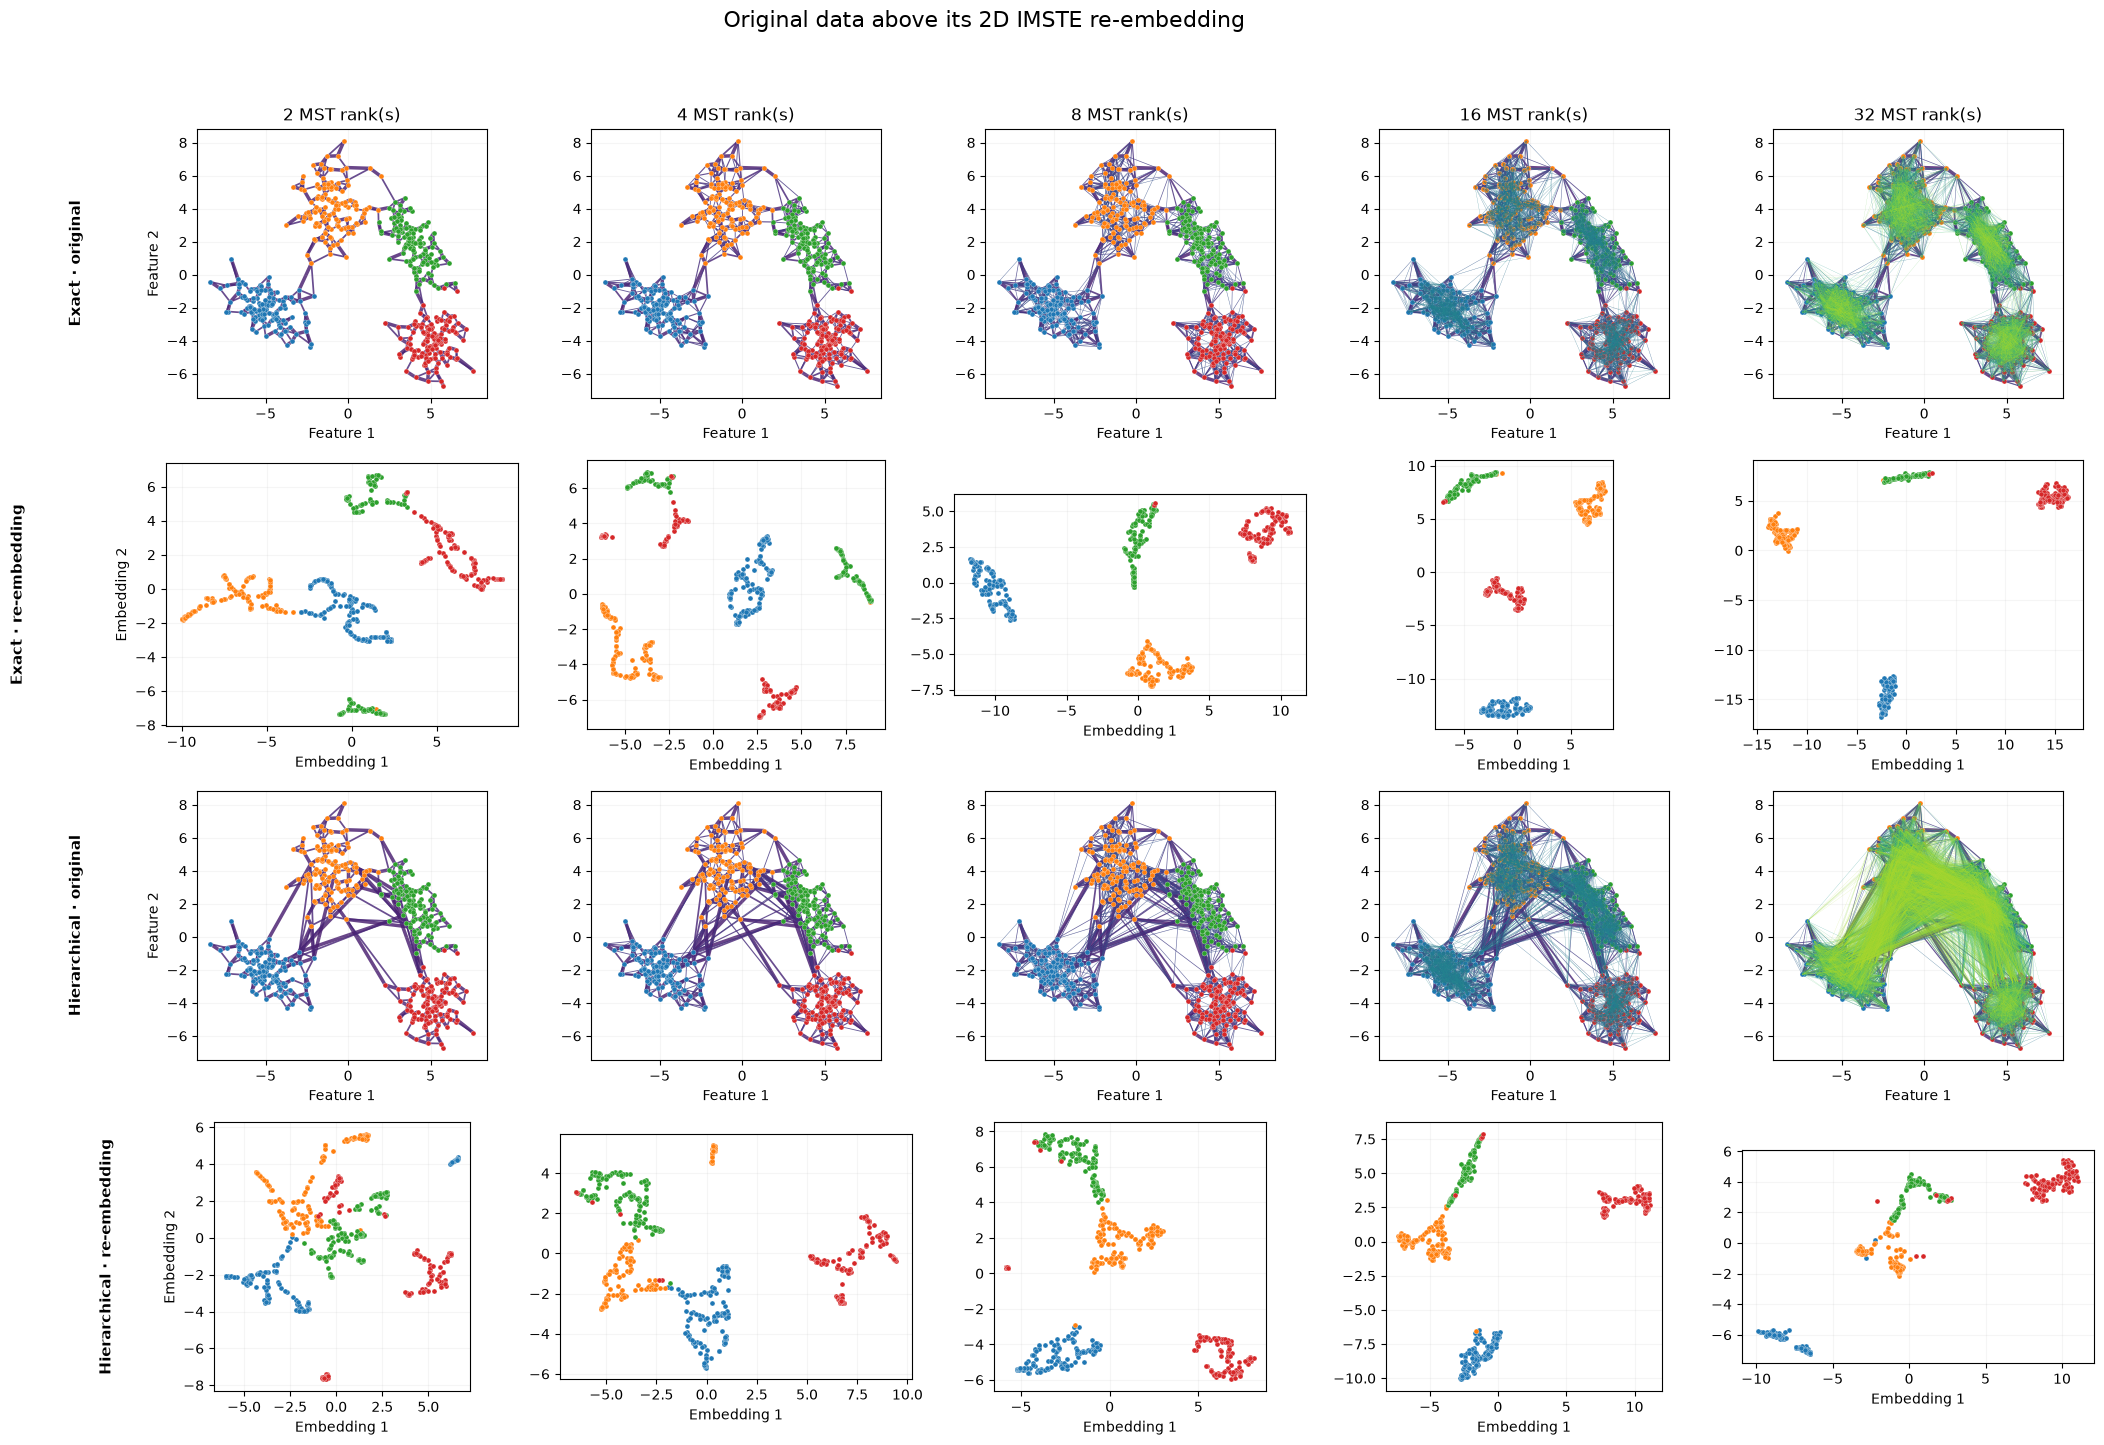

In [18]:
rng = np.random.default_rng(RANDOM_SEED)
cluster_colors = plt.get_cmap('tab10')(np.arange(len(GAUSSIAN_CENTERS)))
clouds, labels = [], []
for cluster_id, center in enumerate(GAUSSIAN_CENTERS):
    angle = rng.uniform(0, 2 * np.pi)
    rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    scales = rng.uniform(*COVARIANCE_AXIS_SCALE_RANGE, size=2)
    covariance = rotation @ np.diag(scales ** 2) @ rotation.T
    clouds.append(rng.multivariate_normal(center, covariance, size=POINTS_PER_CLUSTER))
    labels.extend([cluster_id] * POINTS_PER_CLUSTER)
X, labels = np.vstack(clouds), np.asarray(labels)

rank_colors = plt.get_cmap('viridis')(np.linspace(0.08, 0.88, max(MST_RANKS)))
embeddings, ranked_graphs = {}, {}
for graph_mode in ('exact', 'hierarchical'):
    for iteration in MST_RANKS:
        local_msts = HIERARCHICAL_N_LOCAL_MSTS_BY_PANEL[iteration]
        model = IteratedMinimumSpanningTreeEmbedder(
            graph_mode=graph_mode, n_msts=iteration, n_components=2,
            n_clusters=HIERARCHICAL_N_CLUSTERS,
            n_coarse_msts=HIERARCHICAL_N_COARSE_MSTS,
            n_local_msts=local_msts, minibatch_size=64,
            n_epochs=IMSTE_N_EPOCHS, batch_size=IMSTE_BATCH_SIZE,
            random_state=RANDOM_SEED, device=IMSTE_DEVICE,
        )
        embeddings[graph_mode, iteration] = model.fit_transform(X)
        ranks = np.rint(1.0 / model.graph_weights_).astype(int)
        ranked_graphs[graph_mode, iteration] = [
            model.graph_edges_[ranks == rank] for rank in range(1, iteration + 1)
        ]

fig, axes = plt.subplots(4, len(MST_RANKS), figsize=(4.5 * len(MST_RANKS), 15))
for algorithm_index, graph_mode in enumerate(('exact', 'hierarchical')):
    for col, iteration in enumerate(MST_RANKS):
        Y = embeddings[graph_mode, iteration]
        edges_by_rank = ranked_graphs[graph_mode, iteration]
        for view_index, coordinates in enumerate((X, Y)):
            row, ax = algorithm_index * 2 + view_index, axes[algorithm_index * 2 + view_index, col]
            if view_index == 0:
                for rank, edges in enumerate(edges_by_rank, start=1):
                    if len(edges):
                        ax.add_collection(LineCollection(
                            coordinates[edges], colors=[rank_colors[rank - 1]],
                            linewidths=2.5 / rank, alpha=0.82, zorder=rank))
            for cluster_id, color in enumerate(cluster_colors):
                mask = labels == cluster_id
                ax.scatter(coordinates[mask, 0], coordinates[mask, 1], s=13,
                           color=color, edgecolor='white', linewidth=0.2, zorder=10)
            ax.autoscale_view()
            ax.set_aspect('equal', adjustable='box')
            ax.grid(alpha=0.12)
            ax.set_xlabel('Feature 1' if view_index == 0 else 'Embedding 1')
            if col == 0:
                ax.set_ylabel('Feature 2' if view_index == 0 else 'Embedding 2')
            if row == 0:
                ax.set_title(f'{iteration} MST rank(s)')
for row, label in enumerate(('Exact · original', 'Exact · re-embedding',
                             'Hierarchical · original', 'Hierarchical · re-embedding')):
    axes[row, 0].text(-0.42, 0.5, label, transform=axes[row, 0].transAxes,
                      rotation=90, ha='center', va='center', fontsize=11, fontweight='bold')
fig.suptitle('Original data above its 2D IMSTE re-embedding', fontsize=16)
fig.tight_layout(rect=[0.07, 0.02, 1, 0.95], h_pad=1.3, w_pad=0.7)
plt.show()